<a href="https://colab.research.google.com/github/raymingchen/ODE/blob/main/x_k_for_various_s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

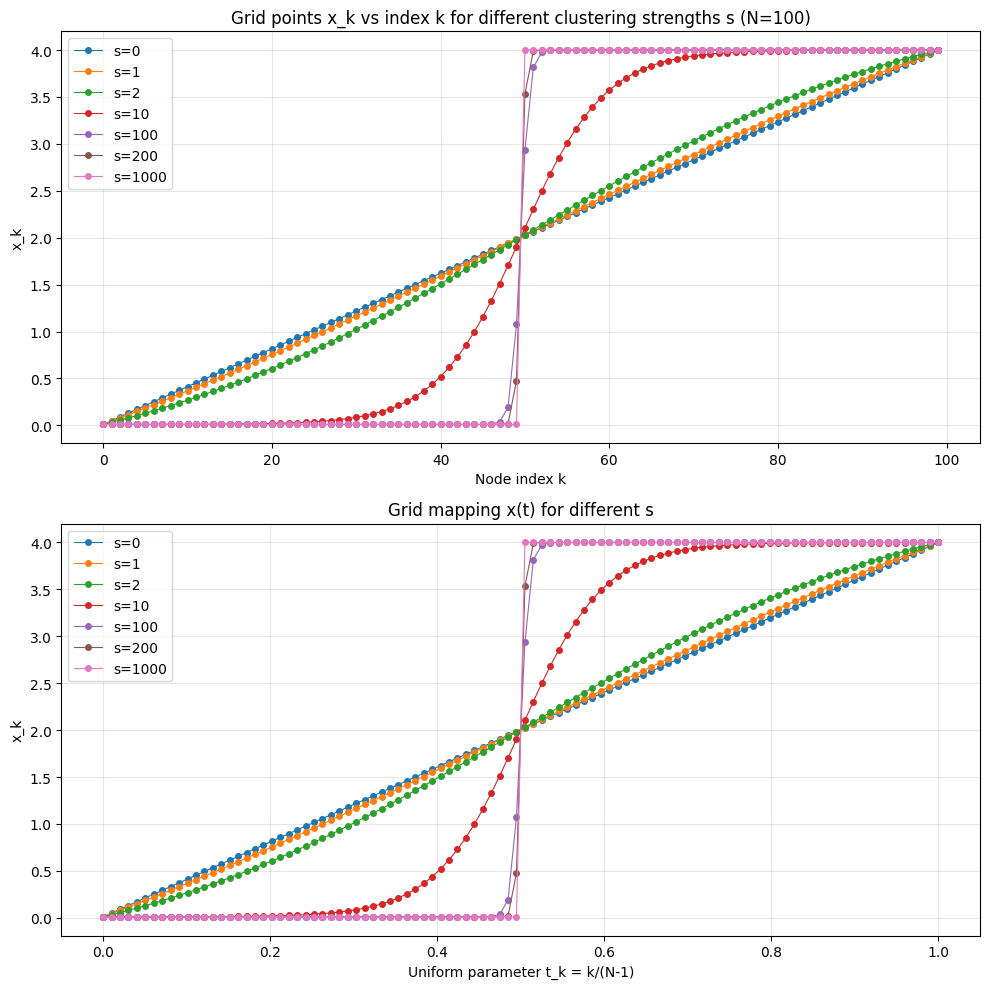

Minimum and maximum grid spacings for each s:
s	min(h)	max(h)	ratio max/min
0	4.030e-02	4.030e-02	1.000e+00
1	3.445e-02	4.361e-02	1.266e+00
2	2.257e-02	5.292e-02	2.345e+00
10	4.055e-05	2.014e-01	4.965e+03
100	0.000e+00	1.860e+00	inf
200	0.000e+00	3.056e+00	inf
1000	0.000e+00	3.990e+00	inf

First 10 and last 10 x_k values for s=1:
First 10: [0.01       0.04445423 0.07922601 0.11431256 0.1497109  0.18541789
 0.22143022 0.25774436 0.29435663 0.33126315]
Last 10:  [3.67873685 3.71564337 3.75225564 3.78856978 3.82458211 3.8602891
 3.89568744 3.93077399 3.96554577 4.        ]

First 10 and last 10 x_k values for s=10:
First 10: [0.01       0.01004055 0.01009018 0.01015092 0.01022526 0.01031623
 0.01042757 0.01056382 0.01073056 0.01093461]
Last 10:  [3.99906539 3.99926944 3.99943618 3.99957243 3.99968377 3.99977474
 3.99984908 3.99990982 3.99995945 4.        ]


/tmp/ipykernel_595/1742130180.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"{s}\t{np.min(h):.3e}\t{np.max(h):.3e}\t{np.max(h)/np.min(h):.3e}")


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Grid generation function
# ------------------------------------------------------------
def generate_grid(alpha, beta, N, s):
    """
    Generate clustered grid points using the tanh mapping.

    Parameters:
        alpha, beta : domain endpoints
        N           : number of points (including boundaries)
        s           : clustering strength (>=0)

    Returns:
        x : array of grid points
    """
    t = np.linspace(0, 1, N)
    if s == 0:
        x = alpha + (beta - alpha) * t
    else:
        x = alpha + (beta - alpha) * (np.tanh(s * (t - 0.5)) / np.tanh(s / 2) + 1.0) / 2.0
    x[0]  = alpha
    x[-1] = beta
    return x

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
alpha, beta = 0.01, 4.0
N = 100  # number of points (use 100 for clarity)
s_values = [0, 1, 2, 10, 100, 200, 1000]

# ------------------------------------------------------------
# Generate grids
# ------------------------------------------------------------
grids = {}
for s in s_values:
    grids[s] = generate_grid(alpha, beta, N, s)

# ------------------------------------------------------------
# Plot 1: x_k vs index k (shows clustering pattern)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Subplot 1: scatter plot of x_k vs k
ax = axes[0]
for s, x in grids.items():
    ax.plot(range(N), x, 'o-', label=f's={s}', markersize=4, linewidth=0.8)
ax.set_xlabel('Node index k')
ax.set_ylabel('x_k')
ax.set_title(f'Grid points x_k vs index k for different clustering strengths s (N={N})')
ax.legend()
ax.grid(alpha=0.3)

# Subplot 2: x_k as a function of the uniform parameter t_k (should show the mapping)
# We reuse t = np.linspace(0,1,N)
t = np.linspace(0, 1, N)
ax2 = axes[1]
for s, x in grids.items():
    ax2.plot(t, x, 'o-', label=f's={s}', markersize=4, linewidth=0.8)
ax2.set_xlabel('Uniform parameter t_k = k/(N-1)')
ax2.set_ylabel('x_k')
ax2.set_title('Grid mapping x(t) for different s')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grid_clustering_comparison.pdf', dpi=300)
plt.show()

# ------------------------------------------------------------
# Additional visualization: histogram of spacings?
# Or simply print min/max spacing for each s
# ------------------------------------------------------------
print("Minimum and maximum grid spacings for each s:")
print("s\tmin(h)\tmax(h)\tratio max/min")
for s, x in grids.items():
    h = np.diff(x)
    print(f"{s}\t{np.min(h):.3e}\t{np.max(h):.3e}\t{np.max(h)/np.min(h):.3e}")

# ------------------------------------------------------------
# Let's also show the actual x values for a selected s=1 and s=10
# to illustrate the distribution
# ------------------------------------------------------------
print("\nFirst 10 and last 10 x_k values for s=1:")
x1 = grids[1]
print("First 10:", x1[:10])
print("Last 10: ", x1[-10:])

print("\nFirst 10 and last 10 x_k values for s=10:")
x10 = grids[10]
print("First 10:", x10[:10])
print("Last 10: ", x10[-10:])